How does food access differ across geography and what factors explain it?

In [178]:
df = pd.read_csv("food_access_final.csv")

print(df.shape)
df.head()

(72531, 153)


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractOMultir,TractHispanic,TractHUNV,TractSNAP,AreaType,FoodDesert,VehicleAccess,low_access_rate,StateCode,Appalachia
0,1001020100,Alabama,Autauga County,1,1912,693,0,0.0,0.000000,0,...,45.0,44.0,6.0,102.0,Urban,Not Food Desert,Has Vehicle,0.991890,AL,False
1,1001020200,Alabama,Autauga County,1,2170,743,0,181.0,8.341014,1,...,55.0,75.0,89.0,156.0,Urban,Food Desert,Has Vehicle,0.581102,AL,False
2,1001020300,Alabama,Autauga County,1,3373,1256,0,0.0,0.000000,0,...,117.0,87.0,99.0,172.0,Urban,Not Food Desert,Has Vehicle,0.460037,AL,False
3,1001020400,Alabama,Autauga County,1,4386,1722,0,0.0,0.000000,0,...,74.0,85.0,21.0,98.0,Urban,Not Food Desert,Has Vehicle,0.310868,AL,False
4,1001020500,Alabama,Autauga County,1,10766,4082,0,181.0,1.681219,0,...,310.0,355.0,230.0,339.0,Urban,Not Food Desert,No Vehicle,0.245504,AL,False


In [177]:
df.to_csv("food_access_final.csv", index=False)

In [4]:
df['AreaType'] = df['Urban'].map({0: 'Rural', 1: 'Urban'})

df['FoodDesert'] = df['LILATracts_1And10'].map({
    0: 'Not Food Desert',
    1: 'Food Desert'
})

df['VehicleAccess'] = df['HUNVFlag'].map({
    0: 'Has Vehicle',
    1: 'No Vehicle'
})

In [5]:
df.head()

,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP,AreaType,FoodDesert,VehicleAccess
0,1001020100,Alabama,Autauga County,1,1912,693,0,0.0,0.000000,0,...,14.0,0.0,14.0,45.0,44.0,6.0,102.0,Urban,Not Food Desert,Has Vehicle
1,1001020200,Alabama,Autauga County,1,2170,743,0,181.0,8.341014,1,...,5.0,0.0,5.0,55.0,75.0,89.0,156.0,Urban,Food Desert,Has Vehicle
2,1001020300,Alabama,Autauga County,1,3373,1256,0,0.0,0.000000,0,...,17.0,5.0,11.0,117.0,87.0,99.0,172.0,Urban,Not Food Desert,Has Vehicle
3,1001020400,Alabama,Autauga County,1,4386,1722,0,0.0,0.000000,0,...,18.0,4.0,11.0,74.0,85.0,21.0,98.0,Urban,Not Food Desert,Has Vehicle
4,1001020500,Alabama,Autauga County,1,10766,4082,0,181.0,1.681219,0,...,296.0,9.0,48.0,310.0,355.0,230.0,339.0,Urban,Not Food Desert,No Vehicle


In [6]:
df.to_csv("vehicleaccess.csv", index=False)

In [7]:
df['low_access_rate'] = df['LAPOP1_10'] / df['Pop2010']

In [8]:
df = df[df['Pop2010'] > 0]  
df['AreaType'] = df['Urban'].map({0: 'Rural', 1: 'Urban'})

In [9]:
df.groupby('AreaType')['low_access_rate'].mean()

AreaType
Rural    0.225409
Urban    0.391026
Name: low_access_rate, dtype: float64

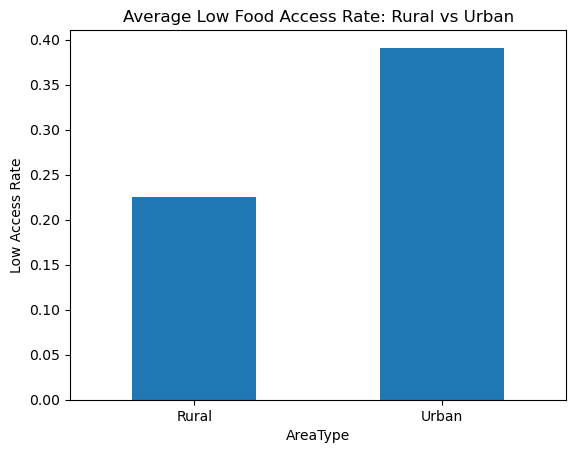

In [10]:
import matplotlib.pyplot as plt

df.groupby('AreaType')['low_access_rate'].mean().plot(kind='bar')
plt.title("Average Low Food Access Rate: Rural vs Urban")
plt.xticks([0,1], ['Rural', 'Urban'], rotation=0)
plt.ylabel("Low Access Rate")

plt.savefig("01_rural_vs_urban.png", dpi=300, bbox_inches='tight')

plt.show()

Urban census tracts have a higher average low food access rate (39.1%) compared to rural tracts (22.5%). This suggests that food access issues are not limited to rural areas and may be more concentrated in urban populations.

Compare ONLY low-income tracts

In [11]:
df.groupby('LowIncomeTracts')['low_access_rate'].mean()

LowIncomeTracts
0    0.389247
1    0.318126
Name: low_access_rate, dtype: float64

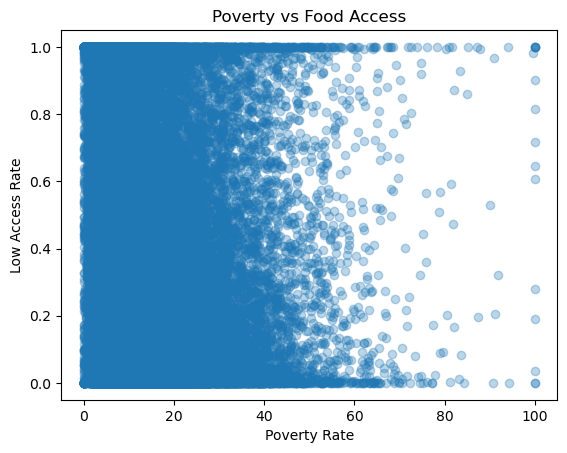

In [12]:
plt.scatter(df['PovertyRate'], df['low_access_rate'], alpha=0.3)
plt.xlabel("Poverty Rate")
plt.ylabel("Low Access Rate")
plt.title("Poverty vs Food Access")

plt.savefig(
    "povertyvsfoodaccessnational.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

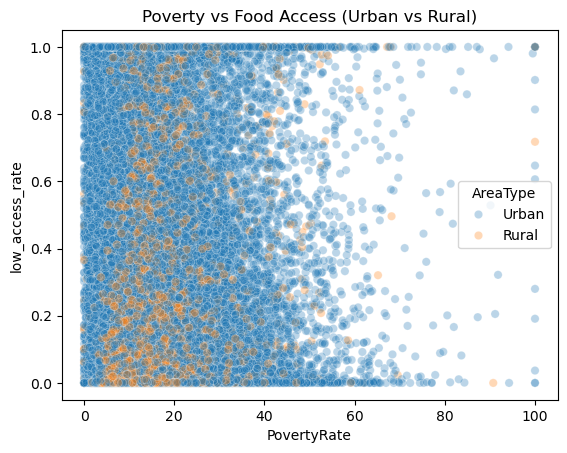

In [13]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x='PovertyRate',
    y='low_access_rate',
    hue='AreaType',
    alpha=0.3
)
plt.title("Poverty vs Food Access (Urban vs Rural)")

plt.savefig(
    "02_poverty_vs_food_access.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [181]:
print(df[['PovertyRate', 'low_access_rate']].describe())

        PovertyRate  low_access_rate
count  72528.000000     42574.000000
mean      15.183628         0.362286
std       11.919764         0.330087
min        0.000000         0.000000
25%        6.495831         0.061231
50%       11.951363         0.268185
75%       20.597443         0.610157
max      100.000000         1.000000


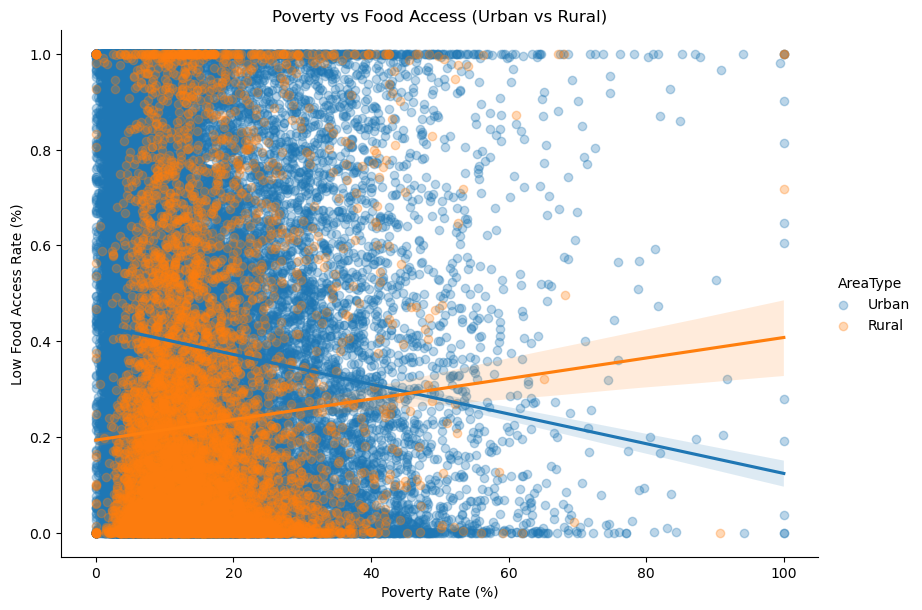

In [184]:
sns.lmplot(
    data=df,
    x='PovertyRate',
    y='low_access_rate',
    hue='AreaType',
    scatter_kws={"alpha":0.3},
    height=6,
    aspect=1.4
)

plt.title("Poverty vs Food Access (Urban vs Rural)")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Low Food Access Rate (%)")

plt.show()

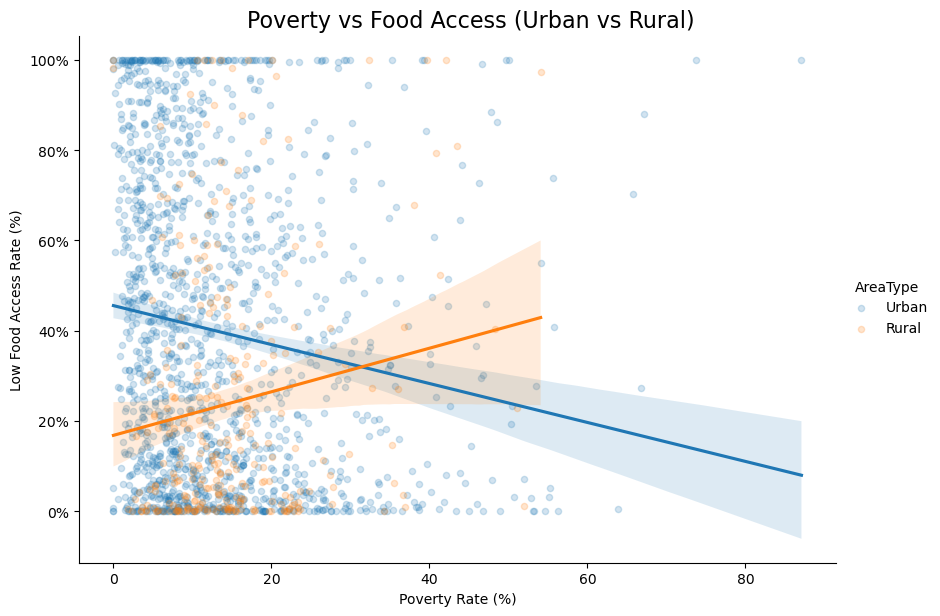

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create consistent sample
sample_df = df.sample(3000, random_state=42)

# Create plot
g = sns.lmplot(
    data=sample_df,
    x='PovertyRate',
    y='low_access_rate',
    hue='AreaType',
    scatter_kws={"alpha":0.2, "s":20},
    height=6,
    aspect=1.4
)

# Title and labels
g.fig.suptitle(
    "Poverty vs Food Access (Urban vs Rural)",
    y=1.02,
    fontsize=16
)

g.set_axis_labels(
    "Poverty Rate (%)",
    "Low Food Access Rate (%)"
)

# Convert y-axis from decimals to percentages visually
g.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Save figure
g.fig.savefig(
    "poverty_vs_food_access.png",
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()

In [14]:
df['AreaType'].value_counts()

AreaType
Urban    55169
Rural    17362
Name: count, dtype: int64

In [15]:
df.groupby('Urban')['low_access_rate'].mean()

Urban
0    0.225409
1    0.391026
Name: low_access_rate, dtype: float64

In [16]:
df.groupby('AreaType')['low_access_rate'].mean()

AreaType
Rural    0.225409
Urban    0.391026
Name: low_access_rate, dtype: float64

In [17]:
df[['low_access_rate', 'MedianFamilyIncome', 'PovertyRate']].corr()

,low_access_rate,MedianFamilyIncome,PovertyRate
low_access_rate,1.000000,0.115744,-0.095765
MedianFamilyIncome,0.115744,1.000000,-0.657712
PovertyRate,-0.095765,-0.657712,1.000000


In [18]:
df.groupby('AreaType')[['low_access_rate', 'PovertyRate']].corr()

low_access_rate  PovertyRate
AreaType                                              
Rural    low_access_rate         1.000000     0.065547
         PovertyRate             0.065547     1.000000
Urban    low_access_rate         1.000000    -0.111802
         PovertyRate            -0.111802     1.000000

In [19]:
df['FoodDesert'] = df['LILATracts_1And10'].map({
    0: 'Not Food Desert',
    1: 'Food Desert'
})

In [20]:
df[['Urban', 'LILATracts_1And10']].head(5)

,Urban,LILATracts_1And10
0,1,0
1,1,1
2,1,0
3,1,0
4,1,0


In [21]:
pd.crosstab(df['AreaType'], df['FoodDesert'], normalize='index')

FoodDesert,Food Desert,Not Food Desert
AreaType,,
Rural,0.077871,0.922129
Urban,0.143940,0.856060


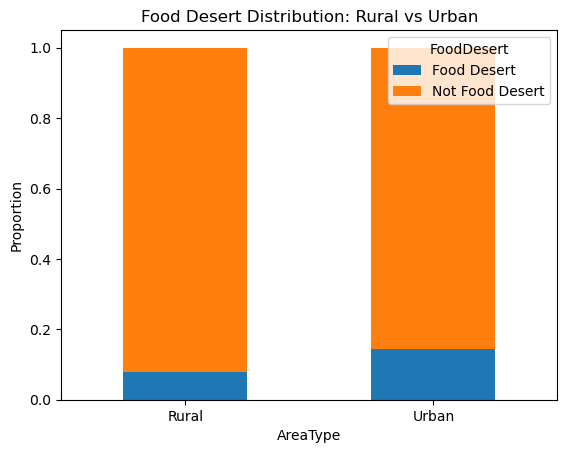

In [22]:
pd.crosstab(df['AreaType'], df['FoodDesert'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Food Desert Distribution: Rural vs Urban")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

In [23]:
df.groupby('FoodDesert')['low_access_rate'].mean()

FoodDesert
Food Desert        0.519753
Not Food Desert    0.318317
Name: low_access_rate, dtype: float64

In [24]:
df[['low_access_rate', 'lakids10share', 'laseniors10share']].corr()

,low_access_rate,lakids10share,laseniors10share
low_access_rate,1.000000,0.815567,0.778443
lakids10share,0.815567,1.000000,0.790211
laseniors10share,0.778443,0.790211,1.000000


In [25]:
df.groupby('LILATracts_Vehicle')['low_access_rate'].mean()

LILATracts_Vehicle
0    0.360543
1    0.370900
Name: low_access_rate, dtype: float64

In [26]:
df.groupby('LILATracts_Vehicle')['low_access_rate'].mean()

LILATracts_Vehicle
0    0.360543
1    0.370900
Name: low_access_rate, dtype: float64

In [27]:
df.sort_values('low_access_rate', ascending=False)[
    ['State', 'County', 'low_access_rate']
].head(10)

,State,County,low_access_rate
36481,Minnesota,Washington County,1.0
36480,Minnesota,Washington County,1.0
19807,Georgia,Muscogee County,1.0
59920,Tennessee,Davidson County,1.0
64570,Texas,Jefferson County,1.0
53907,Oklahoma,Tulsa County,1.0
41359,New Jersey,Hudson County,1.0
57393,Pennsylvania,Philadelphia County,1.0
32051,Massachusetts,Plymouth County,1.0
61260,Texas,Bee County,1.0


In [28]:
state_data = df.groupby('State')['low_access_rate'].mean().sort_values(ascending=False)
state_data.head(10)

State
New Hampshire    0.460586
Alaska           0.451619
Massachusetts    0.438738
Connecticut      0.438317
New Mexico       0.424335
New Jersey       0.422849
Hawaii           0.413402
Arizona          0.409229
Delaware         0.408132
Nevada           0.402871
Name: low_access_rate, dtype: float64

In [29]:
df[['low_access_rate', 'MedianFamilyIncome', 'PovertyRate']].corr()

,low_access_rate,MedianFamilyIncome,PovertyRate
low_access_rate,1.000000,0.115744,-0.095765
MedianFamilyIncome,0.115744,1.000000,-0.657712
PovertyRate,-0.095765,-0.657712,1.000000


In [30]:
df.groupby('LILATracts_Vehicle')['low_access_rate'].mean()

LILATracts_Vehicle
0    0.360543
1    0.370900
Name: low_access_rate, dtype: float64

In [31]:
df.sort_values('low_access_rate', ascending=False)[
    ['State', 'County', 'low_access_rate']
].head(10)

,State,County,low_access_rate
36481,Minnesota,Washington County,1.0
36480,Minnesota,Washington County,1.0
19807,Georgia,Muscogee County,1.0
59920,Tennessee,Davidson County,1.0
64570,Texas,Jefferson County,1.0
53907,Oklahoma,Tulsa County,1.0
41359,New Jersey,Hudson County,1.0
57393,Pennsylvania,Philadelphia County,1.0
32051,Massachusetts,Plymouth County,1.0
61260,Texas,Bee County,1.0


In [32]:
state_data = df.groupby('State', as_index=False)['low_access_rate'].mean()

In [33]:
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT',
    'Delaware': 'DE', 'District of Columbia': 'DC', 'Florida': 'FL',
    'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY',
    'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT',
    'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

In [34]:
state_data['StateCode'] = state_data['State'].map(state_abbrev)

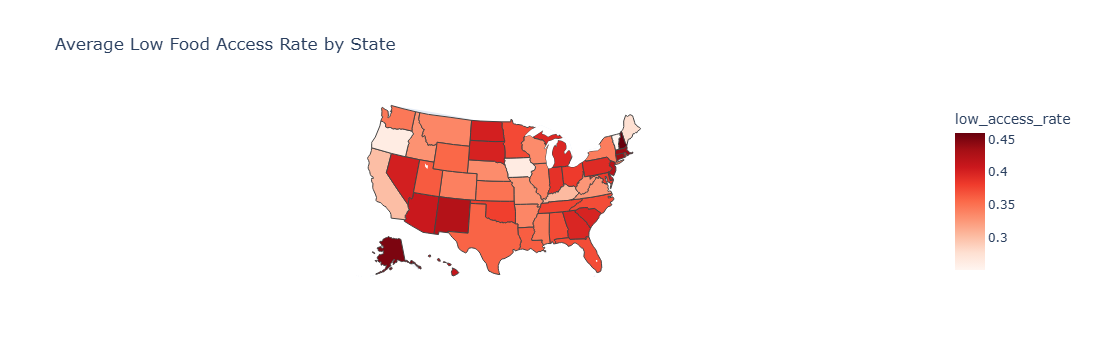

In [35]:
import plotly.express as px

fig = px.choropleth(
    state_data,
    locations='StateCode',
    locationmode='USA-states',
    color='low_access_rate',
    scope='usa',
    color_continuous_scale='Reds',
    title='Average Low Food Access Rate by State'
)

fig.show()

In [36]:
df['StateCode'] = df['State'].map(state_abbrev)

In [37]:
type(state_data)

pandas.core.frame.DataFrame

In [38]:
print(df.columns)

Index(['CensusTract', 'State', 'County', 'Urban', 'Pop2010', 'OHU2010',
       'GroupQuartersFlag', 'NUMGQTRS', 'PCTGQTRS', 'LILATracts_1And10',
       ...
       'TractAIAN', 'TractOMultir', 'TractHispanic', 'TractHUNV', 'TractSNAP',
       'AreaType', 'FoodDesert', 'VehicleAccess', 'low_access_rate',
       'StateCode'],
      dtype='object', length=152)


In [39]:
state_data['State'].unique()[:10]

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida'], dtype=object)

In [40]:
state_data = df.groupby('State', as_index=False)['low_access_rate'].mean()

In [41]:
state_data['StateCode'] = state_data['State'].map(state_abbrev)

In [42]:
state_data[['State', 'StateCode']].head()

,State,StateCode
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA


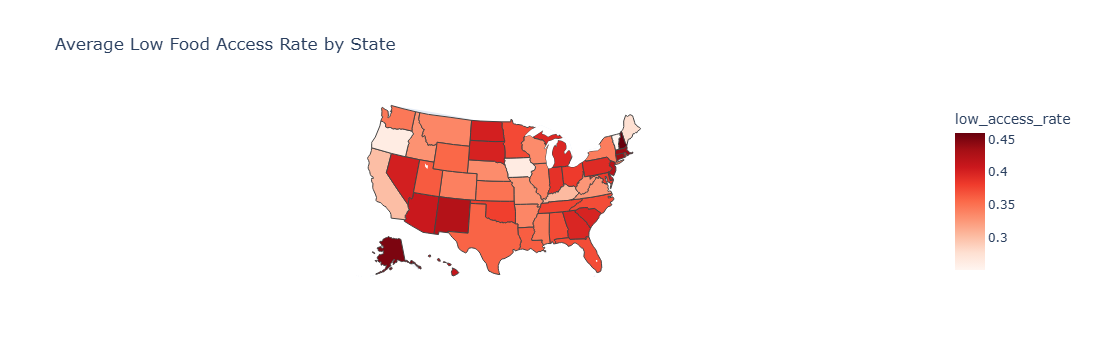

In [43]:
fig = px.choropleth(
    state_data,
    locations='StateCode',  # 👈 use this now
    locationmode='USA-states',
    color='low_access_rate',
    scope='usa',
    color_continuous_scale='Reds',
    title='Average Low Food Access Rate by State'
)

fig.show()

In [44]:
appalachia_states = [
    'West Virginia', 'Kentucky', 'Tennessee',
    'Virginia', 'North Carolina', 'Ohio', 'Pennsylvania'
]

df['Appalachia'] = df['State'].isin(appalachia_states)

In [45]:
df['Appalachia'] = df['State'].isin([
    'West Virginia', 'Kentucky', 'Tennessee',
    'Virginia', 'North Carolina', 'Ohio', 'Pennsylvania'
])

state_data = df.groupby('State', as_index=False)['low_access_rate'].mean()
state_data['Appalachia'] = state_data['State'].isin([
    'West Virginia', 'Kentucky', 'Tennessee',
    'Virginia', 'North Carolina', 'Ohio', 'Pennsylvania'
])

In [46]:
appalachia_states = [
    'West Virginia', 'Kentucky', 'Tennessee',
    'Virginia', 'North Carolina', 'Ohio', 'Pennsylvania'
]

df['Appalachia'] = df['State'].isin(appalachia_states)

state_data = df.groupby('State', as_index=False)['low_access_rate'].mean()
state_data['Appalachia'] = state_data['State'].isin(appalachia_states)

state_data.groupby('Appalachia')['low_access_rate'].mean()

Appalachia
False    0.364726
True     0.354803
Name: low_access_rate, dtype: float64

In [47]:
df.groupby(['Appalachia', 'Urban'])['low_access_rate'].mean()

Appalachia  Urban
False       0        0.242197
            1        0.387490
True        0        0.137966
            1        0.406187
Name: low_access_rate, dtype: float64

In [48]:
appalachia_states = [
    'West Virginia', 'Kentucky', 'Tennessee',
    'Virginia', 'North Carolina', 'Ohio', 'Pennsylvania'
]

# recreate clean state-level dataset
state_data = df.groupby('State', as_index=False)['low_access_rate'].mean()

# add Appalachia flag
state_data['Appalachia'] = state_data['State'].isin(appalachia_states)

# add state code (THIS is what Plotly needs)
state_data['StateCode'] = state_data['State'].map(state_abbrev)

In [49]:
import plotly.express as px

# 1. Rebuild state-level data cleanly
state_data = df.groupby('State', as_index=False)['low_access_rate'].mean()

# 2. Add state abbreviations
state_data['StateCode'] = state_data['State'].map(state_abbrev)

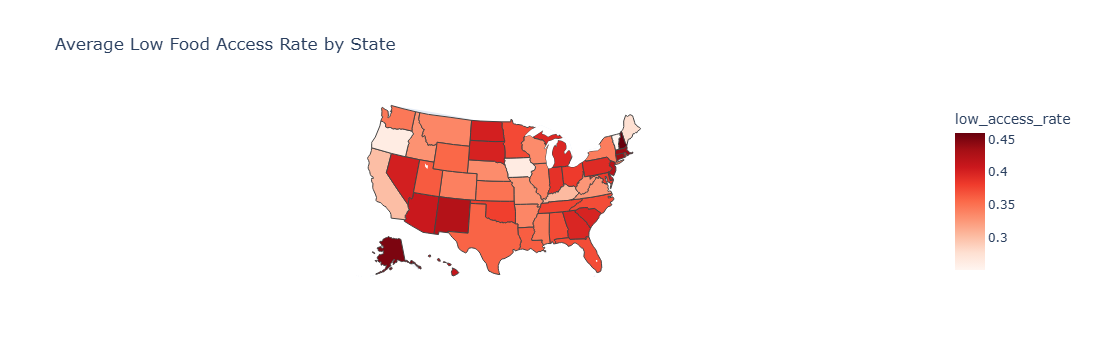

In [50]:
fig = px.choropleth(
    state_data,
    locations='StateCode',
    locationmode='USA-states',
    color='low_access_rate',
    scope='usa',
    color_continuous_scale='Reds',
    hover_name='State',
    title='Average Low Food Access Rate by State'
)

fig.show()

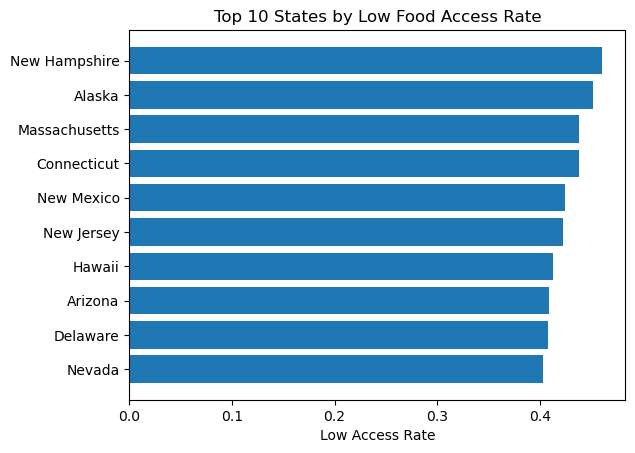

In [51]:
top_states = state_data.sort_values(
    'low_access_rate', ascending=False
).head(10)

import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_states['State'], top_states['low_access_rate'])
plt.title("Top 10 States by Low Food Access Rate")
plt.xlabel("Low Access Rate")
plt.gca().invert_yaxis()
plt.show()

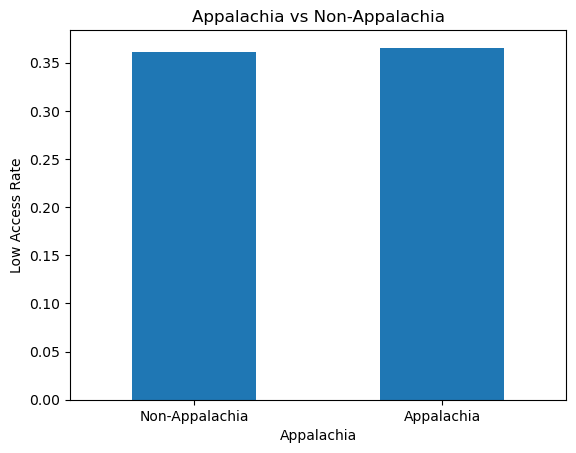

In [52]:
df.groupby('Appalachia')['low_access_rate'].mean().plot(kind='bar')

plt.title("Appalachia vs Non-Appalachia")
plt.xticks([0,1], ['Non-Appalachia', 'Appalachia'], rotation=0)
plt.ylabel("Low Access Rate")
plt.show()

In [53]:
df[df['Appalachia'] == True]['State'].unique()

array(['Kentucky', 'North Carolina', 'Ohio', 'Pennsylvania', 'Tennessee',
       'Virginia', 'West Virginia'], dtype=object)

Does lack of vehicle access increase food insecurity?

In [54]:
df.groupby('HUNVFlag')['low_access_rate'].mean()

HUNVFlag
0    0.356820
1    0.378237
Name: low_access_rate, dtype: float64

In [55]:
df[['MedianFamilyIncome', 'low_access_rate']].corr()

,MedianFamilyIncome,low_access_rate
MedianFamilyIncome,1.000000,0.115744
low_access_rate,0.115744,1.000000


In [56]:
df['VehicleAccess'] = df['HUNVFlag'].map({
    0: 'Has Vehicle',
    1: 'No Vehicle'
})

In [57]:
df.groupby('VehicleAccess')['low_access_rate'].mean()

VehicleAccess
Has Vehicle    0.356820
No Vehicle     0.378237
Name: low_access_rate, dtype: float64

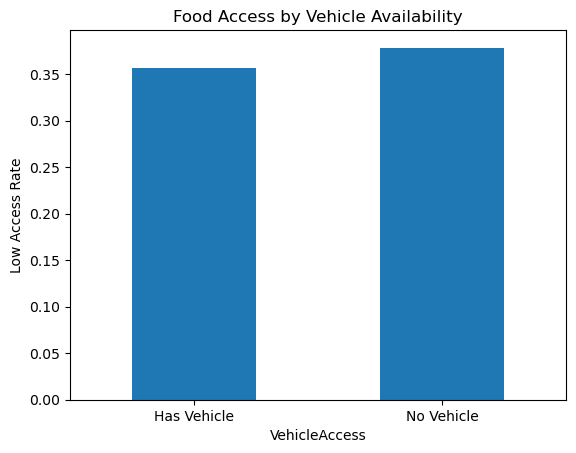

In [58]:
df.groupby('VehicleAccess')['low_access_rate'].mean().plot(kind='bar')

plt.title("Food Access by Vehicle Availability")
plt.ylabel("Low Access Rate")
plt.xticks(rotation=0)
plt.show()

In [59]:
pd.crosstab(
    df['AreaType'],
    df['VehicleAccess'],
    values=df['low_access_rate'],
    aggfunc='mean'
)

VehicleAccess,Has Vehicle,No Vehicle
AreaType,,
Rural,0.234166,0.181263
Urban,0.386424,0.403218


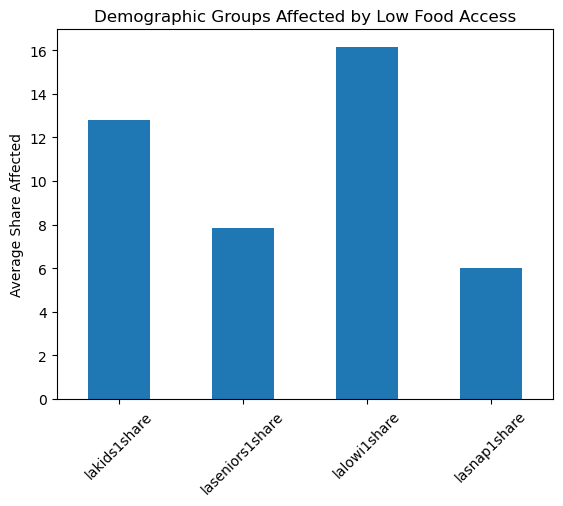

In [60]:
demo_cols = [
    'lakids1share',
    'laseniors1share',
    'lalowi1share',
    'lasnap1share'
]

df[demo_cols].mean().plot(kind='bar')

plt.title("Demographic Groups Affected by Low Food Access")
plt.ylabel("Average Share Affected")
plt.xticks(rotation=45)

plt.savefig(
    "03_demographic_groups.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

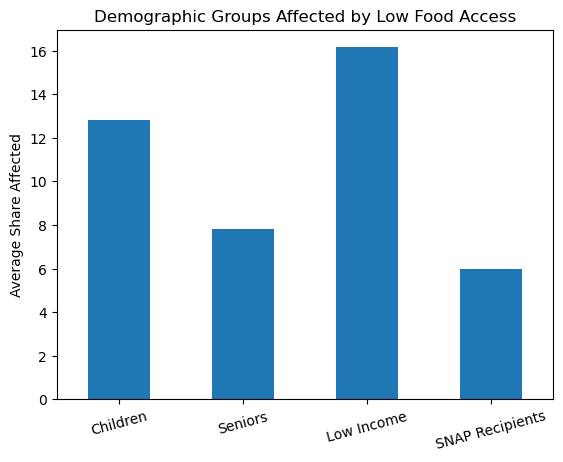

In [179]:
import matplotlib.pyplot as plt

demo_cols = [
    'lakids1share',
    'laseniors1share',
    'lalowi1share',
    'lasnap1share'
]

# More readable labels
labels = [
    'Children',
    'Seniors',
    'Low Income',
    'SNAP Recipients'
]

# Calculate averages
avg_values = df[demo_cols].mean()

# Create chart
avg_values.plot(kind='bar')

# Replace x-axis labels
plt.xticks(
    ticks=range(len(labels)),
    labels=labels,
    rotation=15
)

plt.title("Demographic Groups Affected by Low Food Access")
plt.ylabel("Average Share Affected")

plt.savefig(
    "03_demographic_groups.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [61]:
demo_df = df[demo_cols].copy()

In [62]:
demo_df.mean()

lakids1share       12.810449
laseniors1share     7.826253
lalowi1share       16.149584
lasnap1share        5.995966
dtype: float64

Food access challenges are most concentrated among low-income communities, with children also significantly affected, highlighting the role of economic inequality in shaping access to grocery stores.

Interestingly, SNAP participation rates are lower than overall low-income exposure, suggesting that assistance programs may not fully capture or address all populations experiencing limited food access.

In [63]:
df.groupby('AreaType')[demo_cols].mean()

,lakids1share,laseniors1share,lalowi1share,lasnap1share
AreaType,,,,
Rural,19.545859,12.904123,26.442870,9.370954
Urban,9.488111,5.321521,11.072272,4.332292


In [64]:
race_cols = [
    'lawhite1share',
    'lablack1share',
    'laasian1share'
]

df[race_cols].mean()

lawhite1share    44.084779
lablack1share     5.243153
laasian1share     1.172350
dtype: float64

In [65]:
race_cols = [
    'lawhite1share',
    'lablack1share',
    'laasian1share',
    'laaian1share',
    'lanhopi1share',
    'laomultir1share',
    'lahisp1share'
]

In [66]:
race_labels = {
    'lawhite1share': 'White',
    'lablack1share': 'Black',
    'laasian1share': 'Asian',
    'laaian1share': 'AIAN',
    'lanhopi1share': 'NH/PI',
    'laomultir1share': 'Multiracial',
    'lahisp1share': 'Hispanic'
}

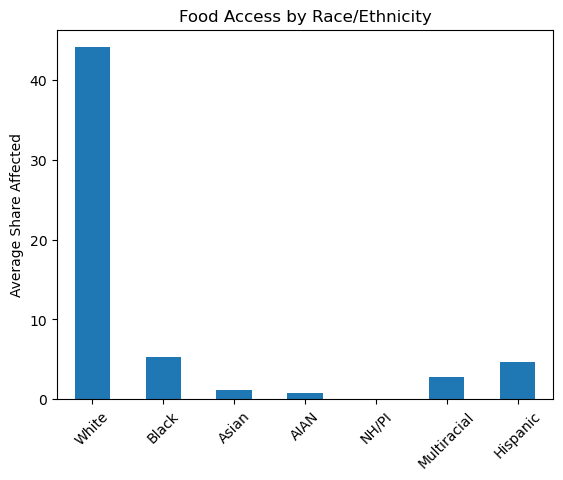

In [67]:
race_means = df[race_cols].mean()
race_means.index = race_means.index.map(race_labels)

race_means.plot(kind='bar')

plt.title("Food Access by Race/Ethnicity")
plt.ylabel("Average Share Affected")
plt.xticks(rotation=45)

plt.savefig(
    "04_national_low_access_map.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [68]:
race_cols = [
    'lawhite1share',
    'lablack1share',
    'laasian1share',
    'laaian1share',
    'lanhopi1share',
    'laomultir1share',
    'lahisp1share'
]

df[race_cols].mean().sort_values(ascending=False)

lawhite1share      44.084779
lablack1share       5.243153
lahisp1share        4.630498
laomultir1share     2.793003
laasian1share       1.172350
laaian1share        0.724721
lanhopi1share       0.063736
dtype: float64

In [69]:
df[race_cols].describe()

,lawhite1share,lablack1share,laasian1share,laaian1share,lanhopi1share,laomultir1share,lahisp1share
count,52542.000000,52542.000000,52542.000000,52542.000000,52542.000000,52542.000000,52542.000000
mean,44.084779,5.243153,1.172350,0.724721,0.063736,2.793003,4.630498
std,33.825300,12.092219,2.947654,4.889577,0.687779,4.390118,9.393902
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.818450,0.191480,0.103843,0.028710,0.000000,0.547404,0.566044
50%,40.720484,0.753498,0.353278,0.136766,0.000000,1.411362,1.558442
75%,75.864602,3.783633,1.026771,0.354394,0.033772,3.078524,4.169336
max,100.000008,100.000002,100.000000,100.000004,85.882354,99.999996,99.999996


While white populations make up the largest share of individuals affected by low food access overall, minority groups such as Black and Hispanic populations show greater variability, with certain areas experiencing disproportionately high concentrations of limited access.

In [70]:
state_black = df.groupby('State')['lablack1share'].mean().reset_index()

In [71]:
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT',
    'Delaware': 'DE', 'District of Columbia': 'DC', 'Florida': 'FL',
    'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY',
    'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT',
    'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

state_black['StateCode'] = state_black['State'].map(state_abbrev)

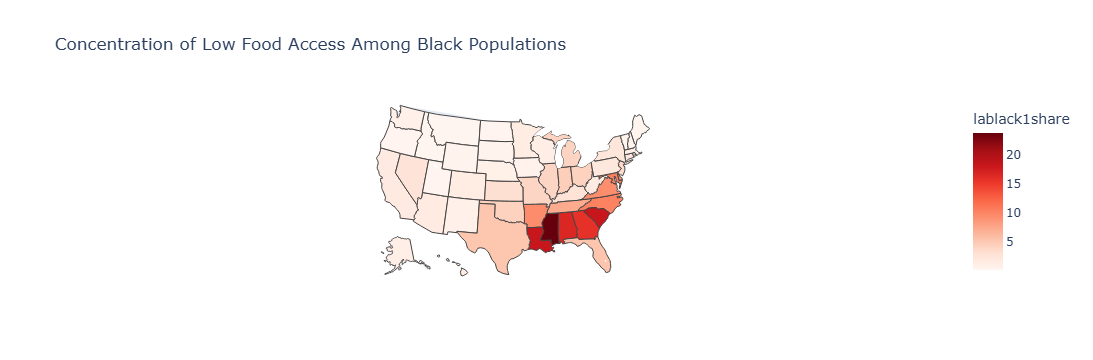

In [72]:
import plotly.express as px

fig = px.choropleth(
    state_black,
    locations='StateCode',
    locationmode='USA-states',
    color='lablack1share',
    scope='usa',
    color_continuous_scale='Reds',
    title='Concentration of Low Food Access Among Black Populations'
)

fig.show()

In [73]:
state_black = df.groupby('State')['lablack1share'].mean().reset_index()
state_hispanic = df.groupby('State')['lahisp1share'].mean().reset_index()

In [74]:
state_black = df.groupby('State')['lablack1share'].mean().reset_index()
state_hispanic = df.groupby('State')['lahisp1share'].mean().reset_index()
state_white = df.groupby('State')['lawhite1share'].mean().reset_index()

state_demo = state_black.merge(state_hispanic, on='State').merge(state_white, on='State')

state_demo.columns = ['State', 'black_share', 'hispanic_share', 'white_share']

In [75]:
state_demo['diversity_gap'] = state_demo['black_share'] + state_demo['hispanic_share'] - state_demo['white_share']

In [76]:
state_demo_sorted = state_demo.sort_values('diversity_gap', ascending=False)
state_demo_sorted.head()

,State,black_share,hispanic_share,white_share,diversity_gap
8,District of Columbia,19.888958,0.794386,4.528011,16.155333
11,Hawaii,1.275055,4.976414,18.139719,-11.888249
31,New Mexico,0.838726,24.659890,39.886707,-14.388092
24,Mississippi,23.817963,1.541732,40.393672,-15.033977
18,Louisiana,18.123795,1.774092,35.654912,-15.757026


In [77]:
state_demo['StateCode'] = state_demo['State'].map(state_abbrev)

In [78]:
print(state_demo.columns)

Index(['State', 'black_share', 'hispanic_share', 'white_share',
       'diversity_gap', 'StateCode'],
      dtype='object')


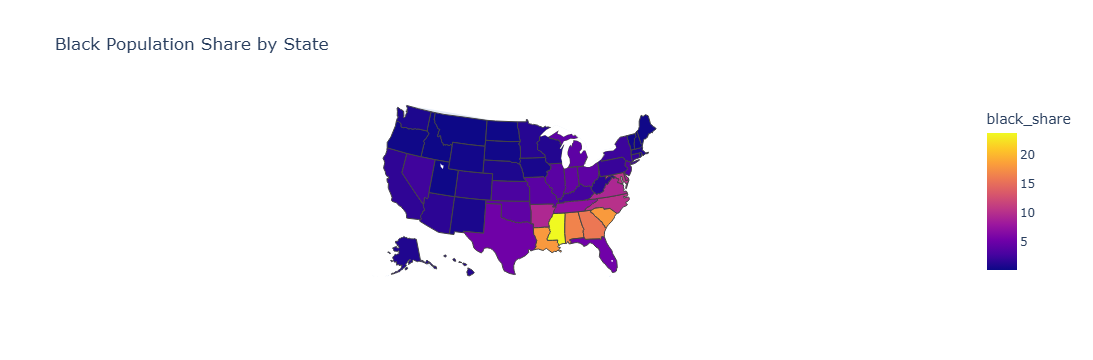

In [79]:
import plotly.express as px

fig = px.choropleth(
    state_demo,
    locations='StateCode',
    locationmode='USA-states',
    color='black_share',
    scope='usa',
    title='Black Population Share by State'
)

fig.show()

In [80]:
print(state_demo['StateCode'].head())

0    AL
1    AK
2    AZ
3    AR
4    CA
Name: StateCode, dtype: object


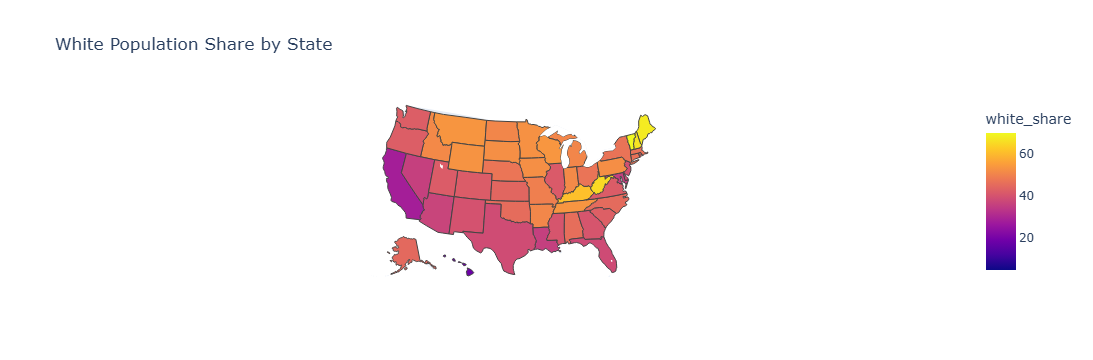

In [81]:
state_demo = state_demo.copy()
state_demo['StateCode'] = state_demo['StateCode'].str.strip()

import plotly.express as px

fig = px.choropleth(
    state_demo,
    locations='StateCode',
    locationmode='USA-states',
    color='white_share',
    scope='usa',
    title='White Population Share by State'
)

fig.show()

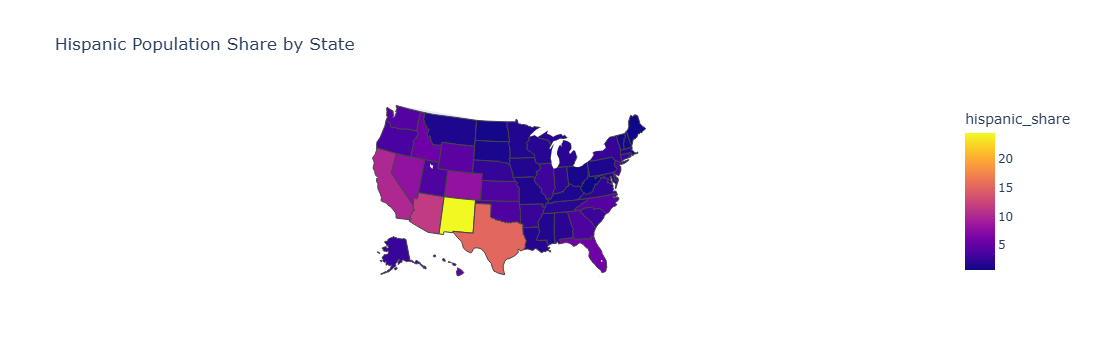

In [82]:
state_demo = state_demo.copy()
state_demo['StateCode'] = state_demo['StateCode'].str.strip()

import plotly.express as px

fig = px.choropleth(
    state_demo,
    locations='StateCode',
    locationmode='USA-states',
    color='hispanic_share',
    scope='usa',
    title='Hispanic Population Share by State'
)

fig.show()

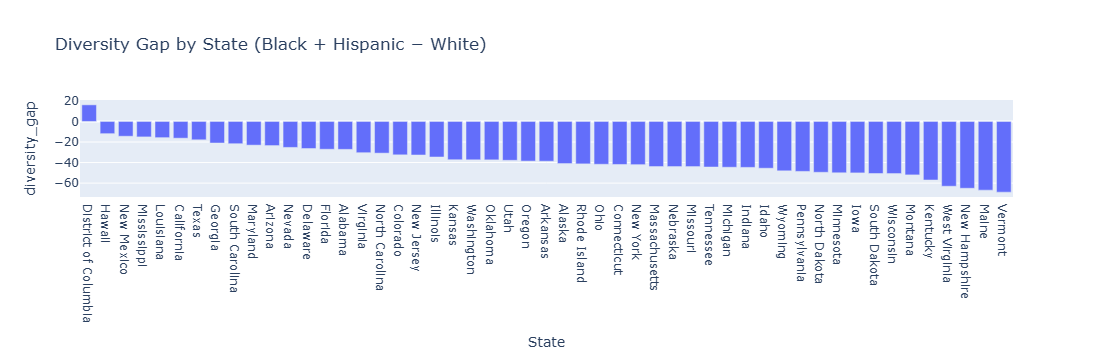

In [83]:
import plotly.express as px

fig = px.bar(
    state_demo_sorted,
    x='State',
    y='diversity_gap',
    title='Diversity Gap by State (Black + Hispanic − White)',
)

fig.show()

This chart shows a composite measure of racial composition by state, calculated as the combined Black and Hispanic population share minus the White population share. Positive values indicate states where non-White populations collectively exceed White populations, while negative values indicate White-majority states.

In [84]:
state_data = df.groupby('State', as_index=False)['low_access_rate'].mean()
state_data['StateCode'] = state_data['State'].map(state_abbrev)

In [85]:
appalachia_states = [
    'West Virginia', 'Kentucky', 'Tennessee',
    'Virginia', 'North Carolina', 'Pennsylvania'
]

state_data['Appalachia'] = state_data['State'].isin(appalachia_states)

In [86]:
state_race = df.groupby('State', as_index=False)[
    ['lablack1share', 'lahisp1share', 'lawhite1share']
].mean()

In [87]:
state_race['StateCode'] = state_race['State'].map(state_abbrev)
state_race['Appalachia'] = state_race['State'].isin(appalachia_states)

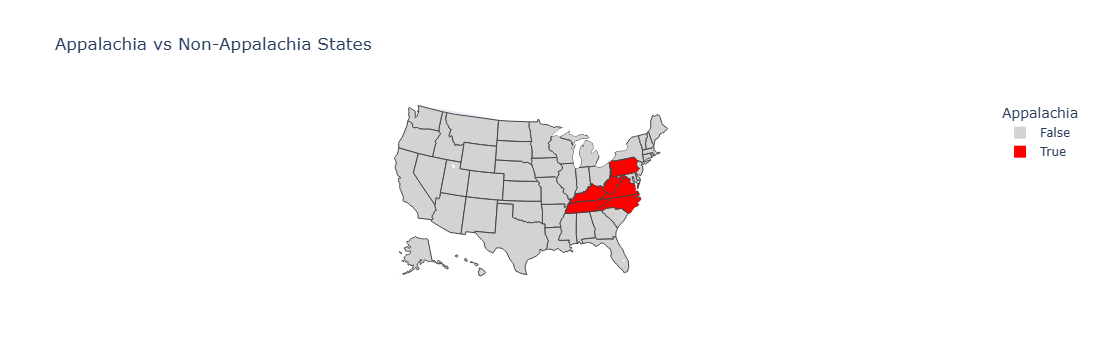

In [88]:
import plotly.express as px

fig = px.choropleth(
    state_data,
    locations='StateCode',
    locationmode='USA-states',
    color='Appalachia',
    scope='usa',
    color_discrete_map={True: 'red', False: 'lightgray'},
    title='Appalachia vs Non-Appalachia States'
)

fig.show()

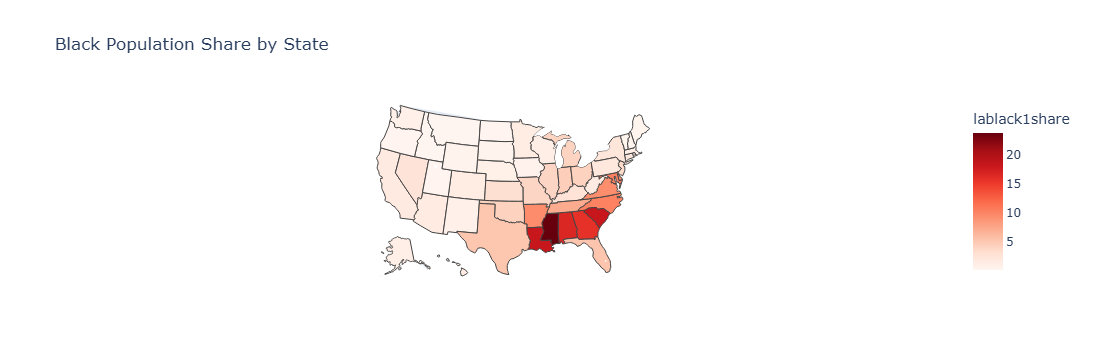

In [89]:
px.choropleth(
    state_race,
    locations='StateCode',
    locationmode='USA-states',
    color='lablack1share',
    scope='usa',
    color_continuous_scale='Reds',
    title='Black Population Share by State'
).show()

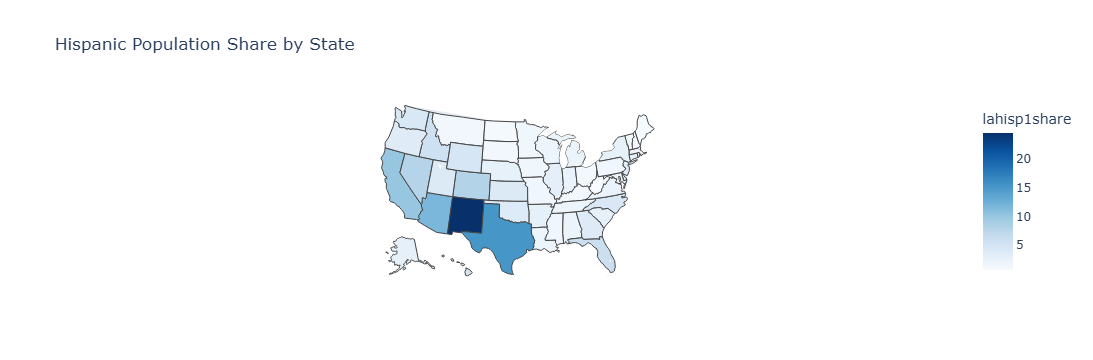

In [90]:
px.choropleth(
    state_race,
    locations='StateCode',
    locationmode='USA-states',
    color='lahisp1share',
    scope='usa',
    color_continuous_scale='Blues',
    title='Hispanic Population Share by State'
).show()

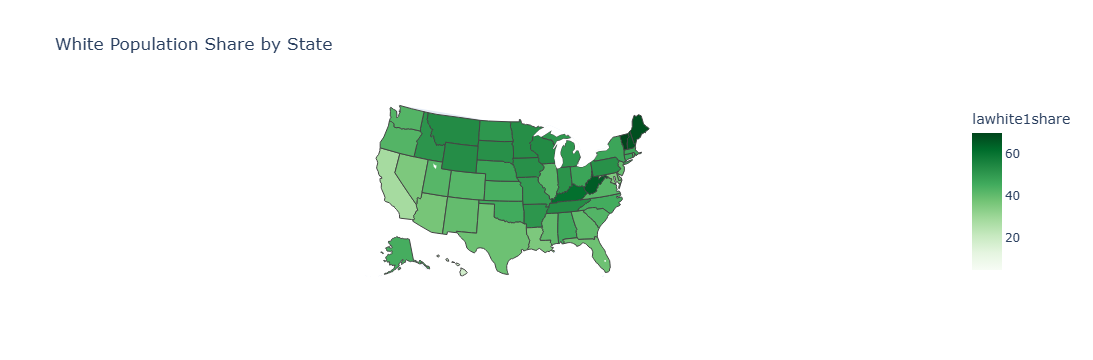

In [91]:
px.choropleth(
    state_race,
    locations='StateCode',
    locationmode='USA-states',
    color='lawhite1share',
    scope='usa',
    color_continuous_scale='Greens',
    title='White Population Share by State'
).show()

In [92]:
appalachia_states = [
    'West Virginia', 'Kentucky', 'Tennessee',
    'Virginia', 'North Carolina', 'Ohio', 'Pennsylvania'
]

app_df = df[df['State'].isin(appalachia_states)].copy()

In [93]:
app_df['low_access_rate'].mean()

0.36550040015288926

In [94]:
df.groupby(df['State'].isin(appalachia_states))['low_access_rate'].mean()

State
False    0.36156
True     0.36550
Name: low_access_rate, dtype: float64

In [95]:
app_df.groupby('Urban')['low_access_rate'].mean()

Urban
0    0.137966
1    0.406187
Name: low_access_rate, dtype: float64

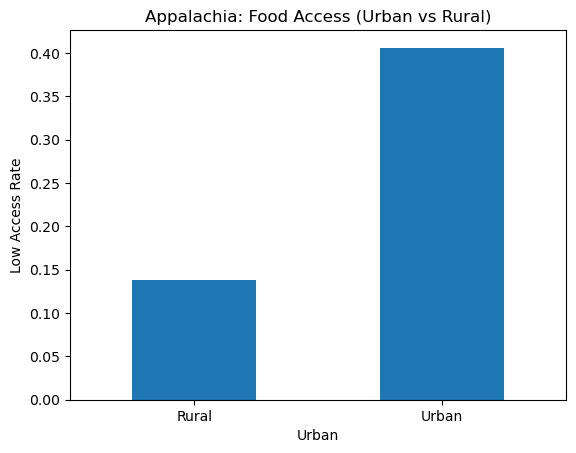

In [96]:
import matplotlib.pyplot as plt

app_df.groupby('Urban')['low_access_rate'].mean().plot(kind='bar')
plt.title('Appalachia: Food Access (Urban vs Rural)')
plt.xticks([0,1], ['Rural','Urban'], rotation=0)
plt.ylabel('Low Access Rate')
plt.show()

In [97]:
app_df.groupby('VehicleAccess')['low_access_rate'].mean()

VehicleAccess
Has Vehicle    0.365881
No Vehicle     0.364668
Name: low_access_rate, dtype: float64

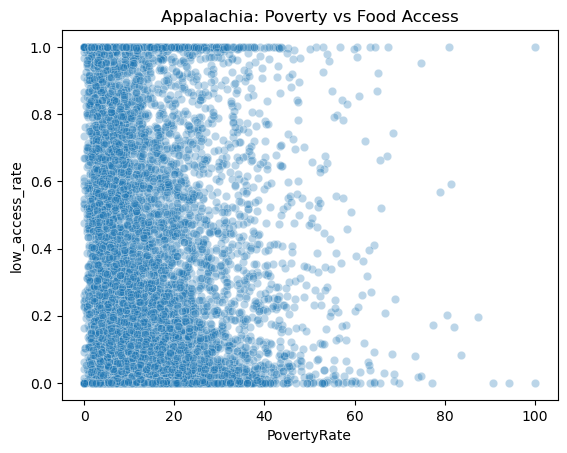

In [98]:
import seaborn as sns

sns.scatterplot(
    data=app_df,
    x='PovertyRate',
    y='low_access_rate',
    alpha=0.3
)
plt.title('Appalachia: Poverty vs Food Access')
plt.show()

In [99]:
race_cols = [
    'lawhite1share',
    'lablack1share',
    'lahisp1share'
]

app_df[race_cols].mean()

lawhite1share    49.977181
lablack1share     5.713005
lahisp1share      1.982212
dtype: float64

In [100]:
wv = df[df['State'] == 'West Virginia'].copy()

In [101]:
wv['low_access_rate'].mean()

0.3266435074722683

In [102]:
wv.groupby('Urban')['low_access_rate'].mean()

Urban
0    0.162565
1    0.434206
Name: low_access_rate, dtype: float64

In [103]:
wv.groupby('VehicleAccess')['low_access_rate'].mean()

VehicleAccess
Has Vehicle    0.338007
No Vehicle     0.311756
Name: low_access_rate, dtype: float64

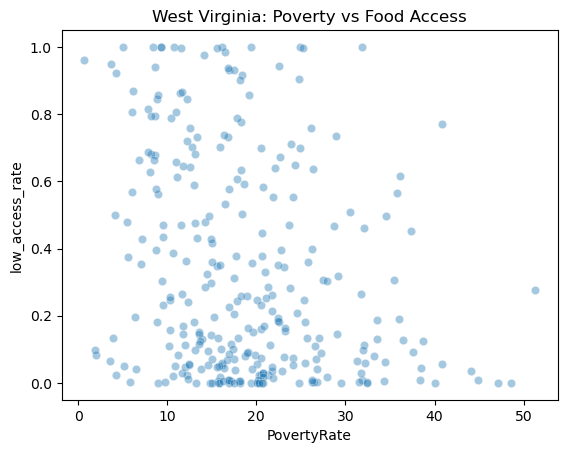

In [104]:
sns.scatterplot(
    data=wv,
    x='PovertyRate',
    y='low_access_rate',
    alpha=0.4
)
plt.title('West Virginia: Poverty vs Food Access')
plt.show()

In [105]:
wv[race_cols].mean()

lawhite1share    65.203953
lablack1share     1.560936
lahisp1share      0.608896
dtype: float64

In [106]:
wv.groupby('County')['low_access_rate'].mean().sort_values(ascending=False).head(25)

County
Gilmer County        0.652971
Pocahontas County    0.640865
Hancock County       0.585946
Berkeley County      0.563792
Jefferson County     0.536899
Pendleton County     0.526470
Brooke County        0.494651
Raleigh County       0.493163
Wayne County         0.483653
Calhoun County       0.447014
Monroe County        0.442377
Kanawha County       0.432382
Marshall County      0.426868
Wetzel County        0.421105
Mercer County        0.372055
Monongalia County    0.363492
Wood County          0.351007
Putnam County        0.349985
Ohio County          0.324604
Logan County         0.318742
Hampshire County     0.315873
Mineral County       0.303479
Morgan County        0.281465
Harrison County      0.281064
Preston County       0.278019
Name: low_access_rate, dtype: float64

In [107]:
wv_county = wv.groupby('County', as_index=False)['low_access_rate'].mean()

# clean names to match geojson
wv_county['County'] = wv_county['County'].str.replace(' County', '', regex=False)

In [108]:
wv_county = wv.groupby('County', as_index=False)['low_access_rate'].mean()

In [109]:
wv_fips = {
    'Barbour': '54001', 'Berkeley': '54003', 'Boone': '54005',
    'Braxton': '54007', 'Brooke': '54009', 'Cabell': '54011',
    'Calhoun': '54013', 'Clay': '54015', 'Doddridge': '54017',
    'Fayette': '54019', 'Gilmer': '54021', 'Grant': '54023',
    'Greenbrier': '54025', 'Hampshire': '54027', 'Hancock': '54029',
    'Hardy': '54031', 'Harrison': '54033', 'Jackson': '54035',
    'Jefferson': '54037', 'Kanawha': '54039', 'Lewis': '54041',
    'Lincoln': '54043', 'Logan': '54045', 'Marion': '54049',
    'Marshall': '54051', 'Mason': '54053', 'McDowell': '54047',
    'Mercer': '54055', 'Mineral': '54057', 'Mingo': '54059',
    'Monongalia': '54061', 'Monroe': '54063', 'Morgan': '54065',
    'Nicholas': '54067', 'Ohio': '54069', 'Pendleton': '54071',
    'Pleasants': '54073', 'Pocahontas': '54075', 'Preston': '54077',
    'Putnam': '54079', 'Raleigh': '54081', 'Randolph': '54083',
    'Ritchie': '54085', 'Roane': '54087', 'Summers': '54089',
    'Taylor': '54091', 'Tucker': '54093', 'Tyler': '54095',
    'Upshur': '54097', 'Wayne': '54099', 'Webster': '54101',
    'Wetzel': '54103', 'Wirt': '54105', 'Wood': '54107',
    'Wyoming': '54109'
}

In [110]:
wv_county['County'] = wv_county['County'].str.replace(' County', '', regex=False)

wv_county['fips'] = wv_county['County'].map(wv_fips)

In [111]:
wv_county[wv_county['fips'].isna()]

,County,low_access_rate,fips


In [112]:
wv_county.head()

,County,low_access_rate,fips
0,Barbour,0.259916,54001
1,Berkeley,0.563792,54003
2,Boone,0.181626,54005
3,Braxton,0.176353,54007
4,Brooke,0.494651,54009


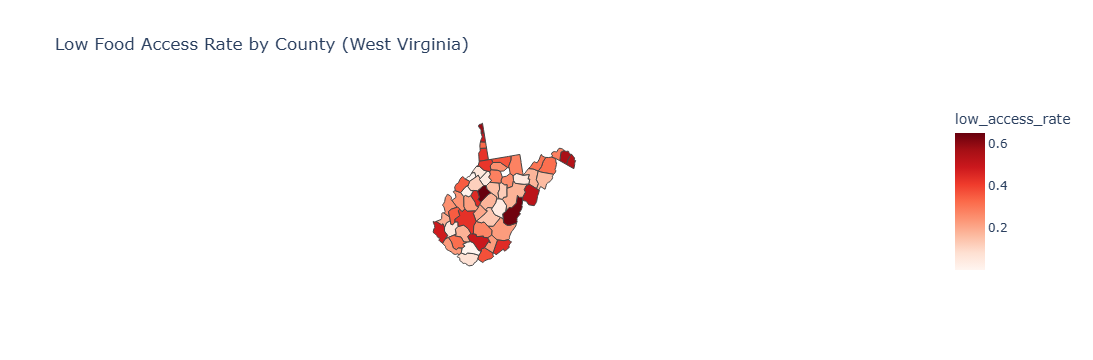

In [113]:
fig = px.choropleth(
    wv_county,
    locations='fips',
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    color='low_access_rate',
    hover_name='County',  # 👈 THIS adds county name in popup
    hover_data={
        'low_access_rate': ':.2f',  # formats nicely
        'fips': False              # hides FIPS (cleaner)
    },
    color_continuous_scale='Reds',
    scope='usa',
    title='Low Food Access Rate by County (West Virginia)'
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [114]:
import osmnx as ox
import pandas as pd

counties = [
    "Kanawha County, West Virginia, USA",
    "Cabell County, West Virginia, USA",
    "Monongalia County, West Virginia, USA",
    "Berkeley County, West Virginia, USA"
]

all_stores = []

for county in counties:
    gdf = ox.features_from_place(
        county,
        tags={"shop": ["supermarket", "grocery"]}
    )
    gdf['county'] = county
    all_stores.append(gdf)

stores = pd.concat(all_stores)

In [115]:
stores = stores.reset_index()

# keep useful columns
stores = stores[['name', 'addr:city', 'geometry']]

In [116]:
import geopandas as gpd

# get WV counties
counties = gpd.read_file('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json')

# filter WV
wv_counties = counties[counties['STATE'] == '54']

In [117]:
stores_gdf = gpd.GeoDataFrame(stores, geometry='geometry', crs='EPSG:4326')

stores_with_county = gpd.sjoin(stores_gdf, wv_counties, how='left', predicate='within')

In [118]:
["Kanawha County, WV",
 "McDowell County, WV",
 "Monongalia County, WV"]

['Kanawha County, WV', 'McDowell County, WV', 'Monongalia County, WV']

In [119]:
snap = pd.read_csv('snap.csv')   # or just 'snap' if already loaded

In [120]:
wv_snap = snap[snap['State'] == 'WV']

In [121]:
print(wv_snap.columns)

Index(['Record ID', 'Store Name', 'Store Type', 'Street Number', 'Street Name',
       'Additional Address', 'City', 'State', 'Zip Code', 'Zip4', 'County',
       'Latitude', 'Longitude', 'Authorization Date', 'End Date'],
      dtype='object')


In [122]:
wv_snap.loc[:, 'County'] = wv_snap['County'].str.replace(' County', '', regex=False)

In [123]:
wv_county['fips'] = wv_county['fips'].astype(str).str.zfill(5)

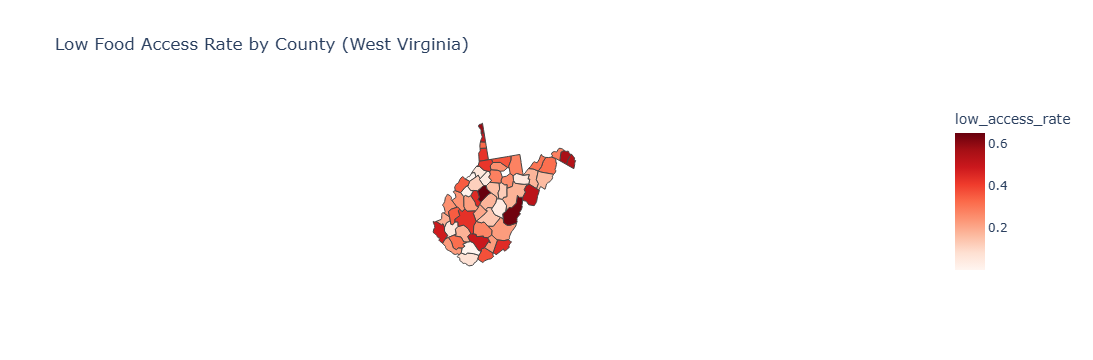

In [124]:
fig.update_geos(fitbounds="locations", visible=False)

In [125]:
print(wv_county.columns)

Index(['County', 'low_access_rate', 'fips'], dtype='object')


In [126]:
print(wv_snap['County'].unique()[:20])

['BARBOUR' 'BERKELEY' 'BOONE' 'BRAXTON' 'BROOKE' 'CABELL' 'CALHOUN' 'CLAY'
 'DODDRIDGE' 'FAYETTE' 'GILMER' 'GRANT' 'GREENBRIER' 'HAMPSHIRE' 'HANCOCK'
 'HARDY' 'HARRISON' 'JACKSON' 'JEFFERSON' 'KANAWHA']


In [127]:
print(wv_county['County'].unique())

['Barbour' 'Berkeley' 'Boone' 'Braxton' 'Brooke' 'Cabell' 'Calhoun' 'Clay'
 'Doddridge' 'Fayette' 'Gilmer' 'Grant' 'Greenbrier' 'Hampshire' 'Hancock'
 'Hardy' 'Harrison' 'Jackson' 'Jefferson' 'Kanawha' 'Lewis' 'Lincoln'
 'Logan' 'Marion' 'Marshall' 'Mason' 'McDowell' 'Mercer' 'Mineral' 'Mingo'
 'Monongalia' 'Monroe' 'Morgan' 'Nicholas' 'Ohio' 'Pendleton' 'Pleasants'
 'Pocahontas' 'Preston' 'Putnam' 'Raleigh' 'Randolph' 'Ritchie' 'Roane'
 'Summers' 'Taylor' 'Tucker' 'Tyler' 'Upshur' 'Wayne' 'Webster' 'Wetzel'
 'Wirt' 'Wood' 'Wyoming']


In [128]:
wv_snap['County'] = wv_snap['County'].str.title().str.strip()

C:\Users\Student\AppData\Local\Temp\ipykernel_6072\3976758324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wv_snap['County'] = wv_snap['County'].str.title().str.strip()


In [129]:
wv_county['County'] = wv_county['County'].str.title().str.strip()

In [130]:
stores_by_county = (
    wv_snap.groupby('County')
    .size()
    .reset_index(name='store_count')
)

In [131]:
wv_county = wv_county.drop(columns=['store_count'], errors='ignore')

wv_county = wv_county.merge(
    stores_by_county,
    on='County',
    how='left'
)

In [132]:
wv_county['store_count'] = wv_county['store_count'].fillna(0)

In [133]:
print(wv_county[['County', 'store_count']].head(10))

      County  store_count
0    Barbour           36
1   Berkeley          190
2      Boone           85
3    Braxton           58
4     Brooke           47
5     Cabell          238
6    Calhoun           36
7       Clay           39
8  Doddridge           20
9    Fayette          154


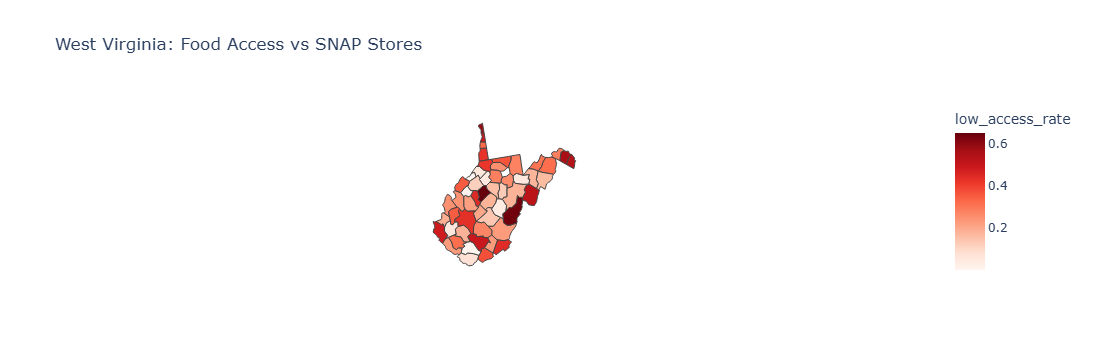

In [134]:
import plotly.express as px

fig = px.choropleth(
    wv_county,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="low_access_rate",
    scope="usa",
    hover_name="County",
    hover_data=["low_access_rate", "store_count"],
    color_continuous_scale="Reds",
    title="West Virginia: Food Access vs SNAP Stores"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [135]:
wv_snap['Store Name'].value_counts().head(20)

Store Name
Marathon                       7
Save A Lot                     5
Fast Stop                      4
Williamson Farmers Market      3
A & P Stop 1                   3
Lewisburg Farmers' Market      3
Sun Valley Country Store       3
Foodway Supermarket            3
Waco Foods, Llc                3
Scarbro Market                 3
Mini Mart                      3
Appalachian General Store      3
The Intersection               3
Glenwood Country Store         3
Sheetz 241                     3
W W Service Center LLC         3
Millstone Grocery              3
Gold Quality Foods             3
Matoaka Market                 3
Quick Check #2                 3
Name: count, dtype: int64

In [136]:
wv_snap['Store Type'].value_counts()

Store Type
Convenience Store            3044
Combination Grocery/Other     910
Supermarket                   259
Small Grocery Store           216
Super Store                   164
Medium Grocery Store          114
Farmers' Market               103
Fruits/Veg Specialty           68
Meat/Poultry Specialty         65
Large Grocery Store            60
Delivery Route                 40
Food Buying Co-op              25
Bakery Specialty               24
Seafood Specialty               7
Unknown                         4
Wholesaler                      3
Military Commissary             1
Name: count, dtype: int64

In [137]:
def food_tier(store_type):
    if store_type in ["Supermarket", "Super Store", "Large Grocery Store"]:
        return "Full Grocery Access"
    
    elif store_type in ["Medium Grocery Store", "Small Grocery Store", "Combination Grocery/Other"]:
        return "Partial Grocery Access"
    
    elif store_type in ["Convenience Store", "Fast Food", "Gas Station"]:
        return "Limited Access"
    
    elif "Farmers" in str(store_type):
        return "Farmers Market"
    
    else:
        return "Other"

In [138]:
wv_snap['FoodAccessTier'] = wv_snap['Store Type'].apply(food_tier)

C:\Users\Student\AppData\Local\Temp\ipykernel_6072\3466186766.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wv_snap['FoodAccessTier'] = wv_snap['Store Type'].apply(food_tier)


In [139]:
tier_counts = pd.crosstab(wv_snap['County'], wv_snap['FoodAccessTier'])

In [140]:
wv_county = wv_county.merge(
    tier_counts,
    on='County',
    how='left'
).fillna(0)

<Axes: >

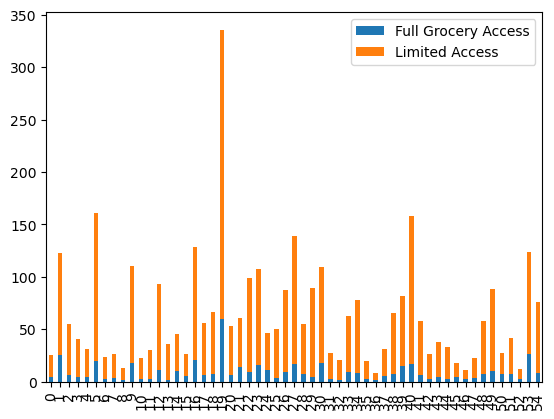

In [141]:
wv_county[['Full Grocery Access', 'Limited Access']].plot(kind='bar', stacked=True)

In [142]:
wv_county['limited_ratio'] = (
    wv_county['Limited Access'] /
    (wv_county['Full Grocery Access'] + 1)
)

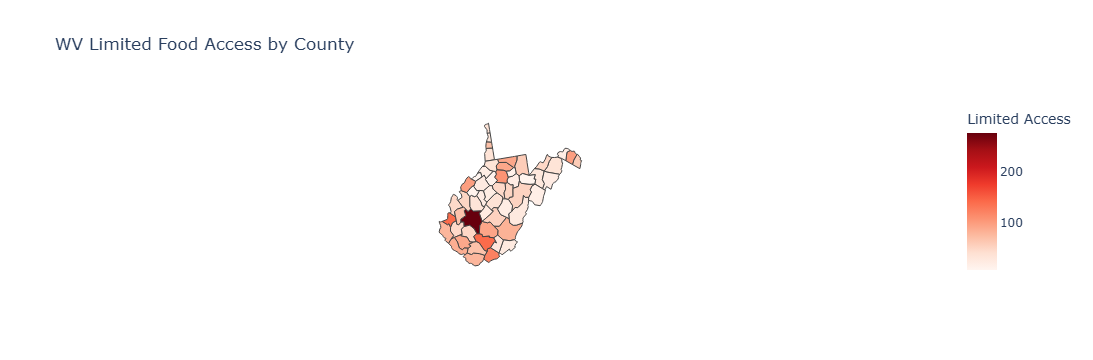

In [143]:
import plotly.express as px

fig = px.choropleth(
    wv_county,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="Limited Access",
    hover_name="County",
    hover_data={
        "Full Grocery Access": True,
        "Limited Access": True,
        "low_access_rate": ":.2f"
    },
    color_continuous_scale="Reds",
    scope="usa",
    title="WV Limited Food Access by County"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

C:\Users\Student\AppData\Local\Temp\ipykernel_6072\2518301908.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


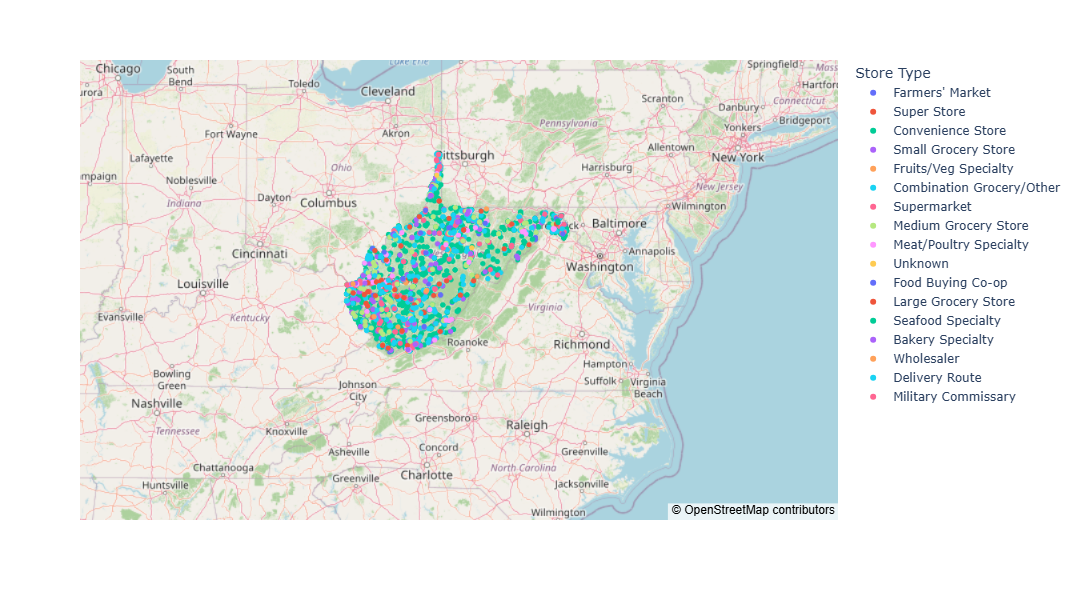

In [144]:
fig = px.scatter_mapbox(
    wv_snap,
    lat="Latitude",
    lon="Longitude",
    color="Store Type",
    hover_name="Store Name",
    hover_data=["City", "County"],
    zoom=5,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [145]:
wv_county['fips'] = wv_county['fips'].astype(str).str.zfill(5)

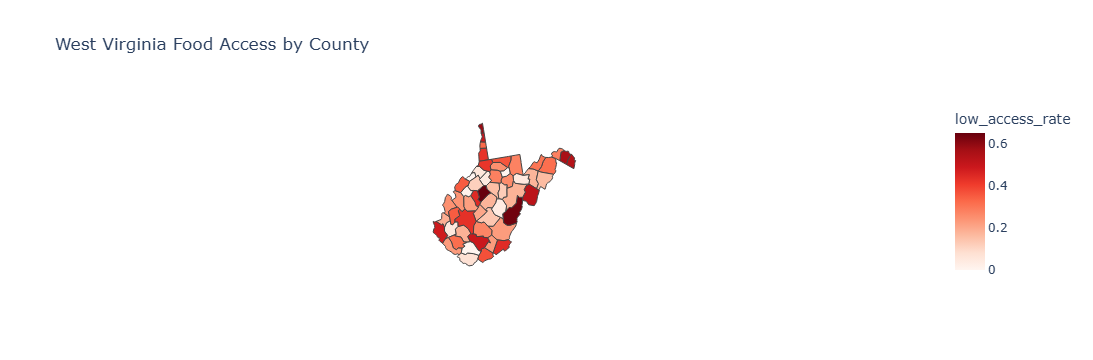

In [146]:
import plotly.express as px

fig = px.choropleth(
    wv_county,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="low_access_rate",
    scope="usa",
    hover_name="County",
    hover_data=["low_access_rate"],
    color_continuous_scale="Reds",
    title="West Virginia Food Access by County"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [147]:
store_count = wv_snap.groupby("County", as_index=False).size()
store_count.columns = ["County", "store_count"]

In [148]:
wv_map = wv_county.merge(store_count, on="County", how="left")

In [149]:
wv_county["County"] = wv_county["County"].str.title()
store_count["County"] = store_count["County"].str.title()

In [150]:
print(store_count)
print(type(store_count))

        County  store_count
0      Barbour           36
1     Berkeley          190
2        Boone           85
3      Braxton           58
4       Brooke           47
5       Cabell          238
6      Calhoun           36
7         Clay           39
8    Doddridge           20
9      Fayette          154
10      Gilmer           31
11       Grant           38
12  Greenbrier          146
13   Hampshire           67
14     Hancock           62
15       Hardy           37
16    Harrison          189
17     Jackson           84
18   Jefferson           95
19     Kanawha          492
20       Lewis           69
21     Lincoln           88
22       Logan          133
23      Marion          150
24    Marshall           67
25       Mason           83
26    Mcdowell          111
27      Mercer          197
28     Mineral           73
29       Mingo          119
30  Monongalia          157
31      Monroe           37
32      Morgan           39
33    Nicholas           98
34        Ohio      

In [151]:
wv_map = wv_county.merge(store_count, on="County", how="left")

In [152]:
print(store_count.columns)
print(wv_map.columns)

Index(['County', 'store_count'], dtype='object')
Index(['County', 'low_access_rate', 'fips', 'store_count_x', 'Farmers Market',
       'Full Grocery Access', 'Limited Access', 'Other',
       'Partial Grocery Access', 'limited_ratio', 'store_count_y'],
      dtype='object')


In [153]:
wv_map["store_count"] = wv_map["store_count_y"]
wv_map = wv_map.drop(columns=["store_count_x", "store_count_y"])

In [154]:
print(wv_map.columns)

Index(['County', 'low_access_rate', 'fips', 'Farmers Market',
       'Full Grocery Access', 'Limited Access', 'Other',
       'Partial Grocery Access', 'limited_ratio', 'store_count'],
      dtype='object')


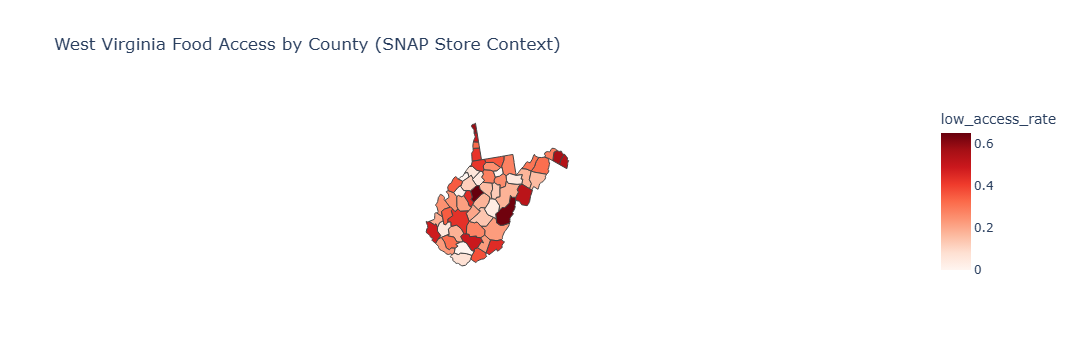

In [155]:
import plotly.express as px

fig = px.choropleth(
    wv_map,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="low_access_rate",
    scope="usa",
    hover_name="County",
    hover_data={
        "low_access_rate": ":.2%",
        "store_count": True,
        "Limited Access": True,
        "Full Grocery Access": True
    },
    color_continuous_scale="Reds",
    title="West Virginia Food Access by County (SNAP Store Context)"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

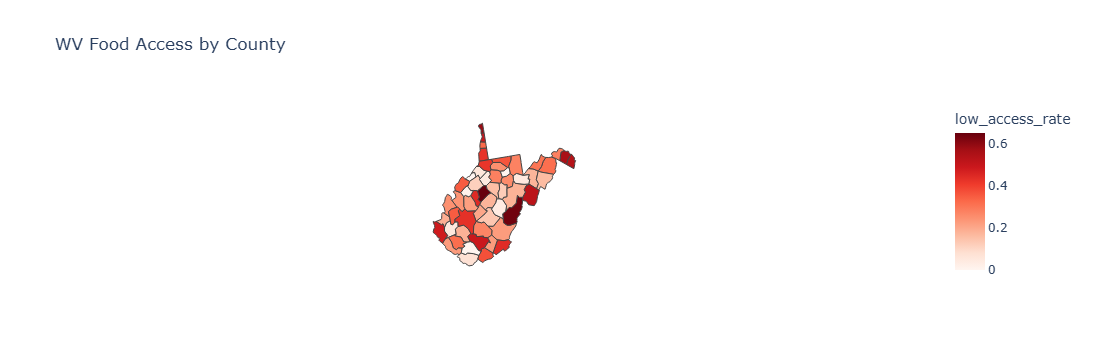

In [156]:
fig = px.choropleth(
    wv_map,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="low_access_rate",
    scope="usa",
    hover_name="County",
    hover_data=["store_count", "low_access_rate"],
    color_continuous_scale="Reds",
    title="WV Food Access by County"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [157]:
wv_map["store_burden_index"] = wv_map["low_access_rate"] * wv_map["store_count"]

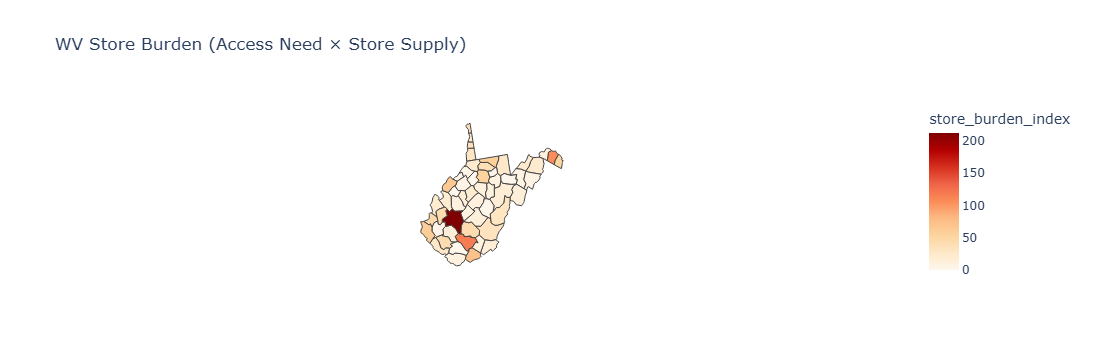

In [158]:
fig = px.choropleth(
    wv_map,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="store_burden_index",
    hover_name="County",
    hover_data=["store_count", "low_access_rate"],
    scope="usa",
    color_continuous_scale="OrRd",
    title="WV Store Burden (Access Need × Store Supply)"
)
fig.update_geos(fitbounds="locations", visible=False)
fig.show()

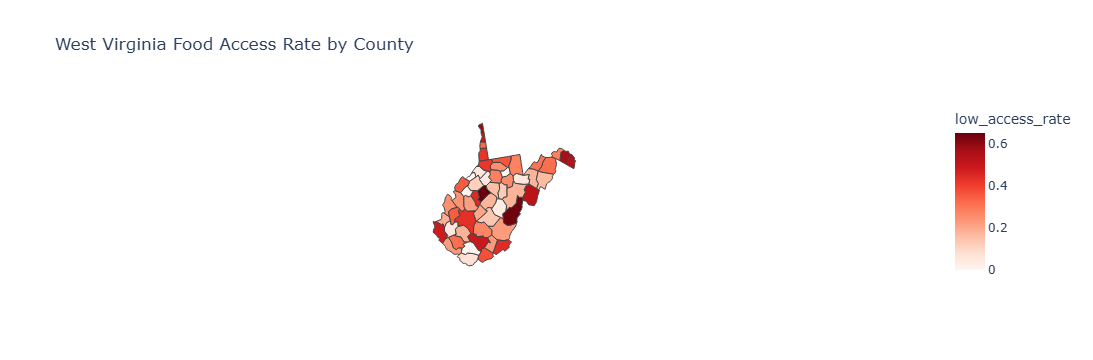

In [159]:
fig = px.choropleth(
    wv_county,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="low_access_rate",
    scope="usa",
    hover_name="County",
    hover_data=["store_count", "low_access_rate"],
    color_continuous_scale="Reds",
    title="West Virginia Food Access Rate by County"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

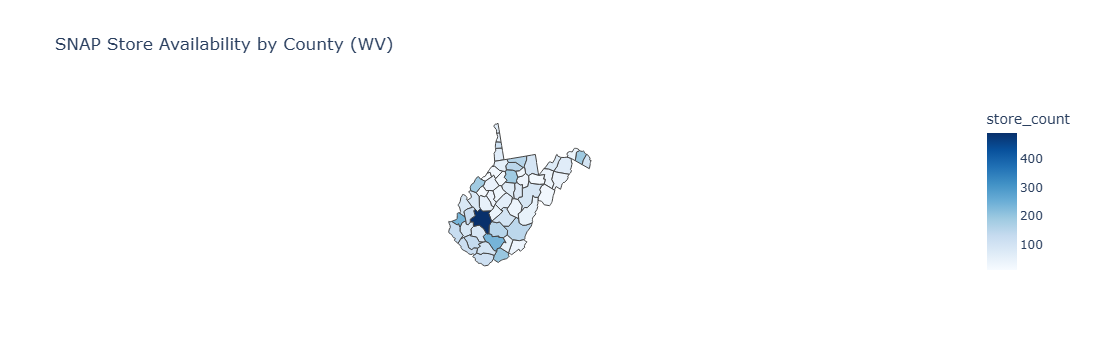

In [160]:
fig = px.choropleth(
    wv_county,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="store_count",
    scope="usa",
    hover_name="County",
    hover_data=["store_count", "low_access_rate"],
    color_continuous_scale="Blues",
    title="SNAP Store Availability by County (WV)"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [161]:
wv_county["access_category"] = pd.cut(
    wv_county["low_access_rate"],
    bins=[0, 0.2, 0.4, 1],
    labels=["Low", "Medium", "High"]
)

In [162]:
wv_county.groupby("access_category", observed=False)["store_count"].mean()

access_category
Low        66.210526
Medium    108.285714
High      110.571429
Name: store_count, dtype: float64

<Axes: title={'center': 'Average SNAP Stores by Food Access Level'}, xlabel='access_category'>

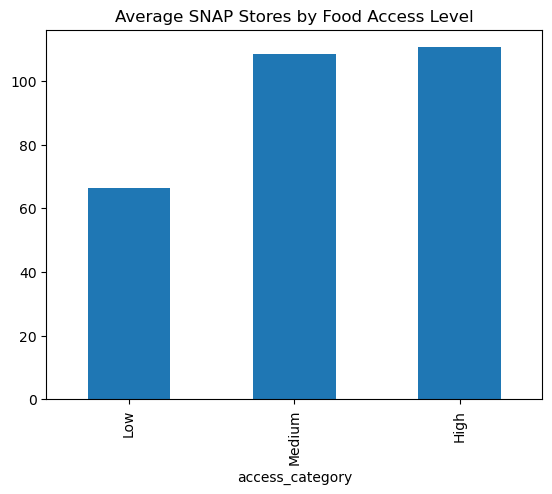

In [163]:
wv_county.groupby("access_category", observed=False)["store_count"].mean().plot(
    kind="bar",
    title="Average SNAP Stores by Food Access Level"
)

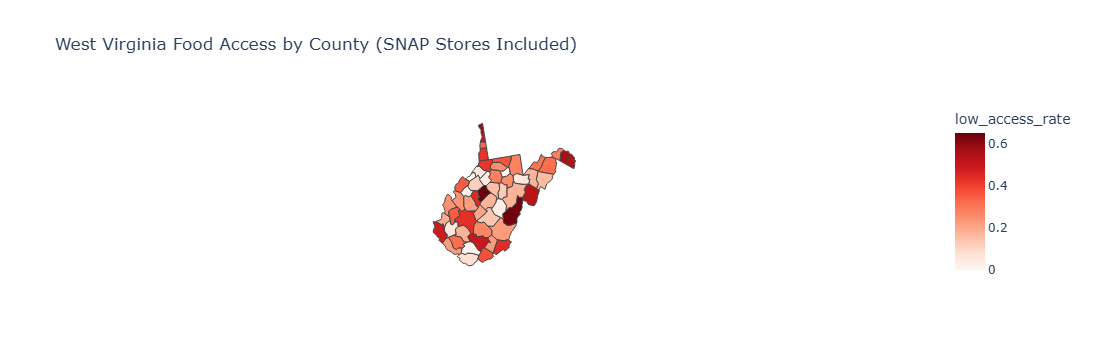

In [164]:
import plotly.express as px

# Ensure FIPS is properly formatted (5 digits)
wv_county["fips"] = wv_county["fips"].astype(str).str.zfill(5)

fig = px.choropleth(
    wv_county,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="low_access_rate",
    scope="usa",
    hover_name="County",
    hover_data={
        "low_access_rate": ":.2%",   # formats as percentage
        "store_count": True          # shows raw store count
    },
    color_continuous_scale="Reds",
    title="West Virginia Food Access by County (SNAP Stores Included)"
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()

In [165]:
top5_low_access = (
    wv_county.sort_values("low_access_rate", ascending=False)
    .head(5)
)

top5_low_access

,County,low_access_rate,fips,store_count,Farmers Market,Full Grocery Access,Limited Access,Other,Partial Grocery Access,limited_ratio,access_category
10,Gilmer,0.652971,54021,31,1,2,20,2,6,6.666667,High
37,Pocahontas,0.640865,54075,46,3,5,26,2,10,4.333333,High
14,Hancock,0.585946,54029,62,0,10,35,0,17,3.181818,High
1,Berkeley,0.563792,54003,190,4,25,98,14,49,3.769231,High
18,Jefferson,0.536899,54037,95,5,7,59,2,22,7.375000,High


In [166]:
top5_counties = top5_low_access["County"].tolist()

wv_snap_top5 = wv_snap[wv_snap["County"].isin(top5_counties)].copy()

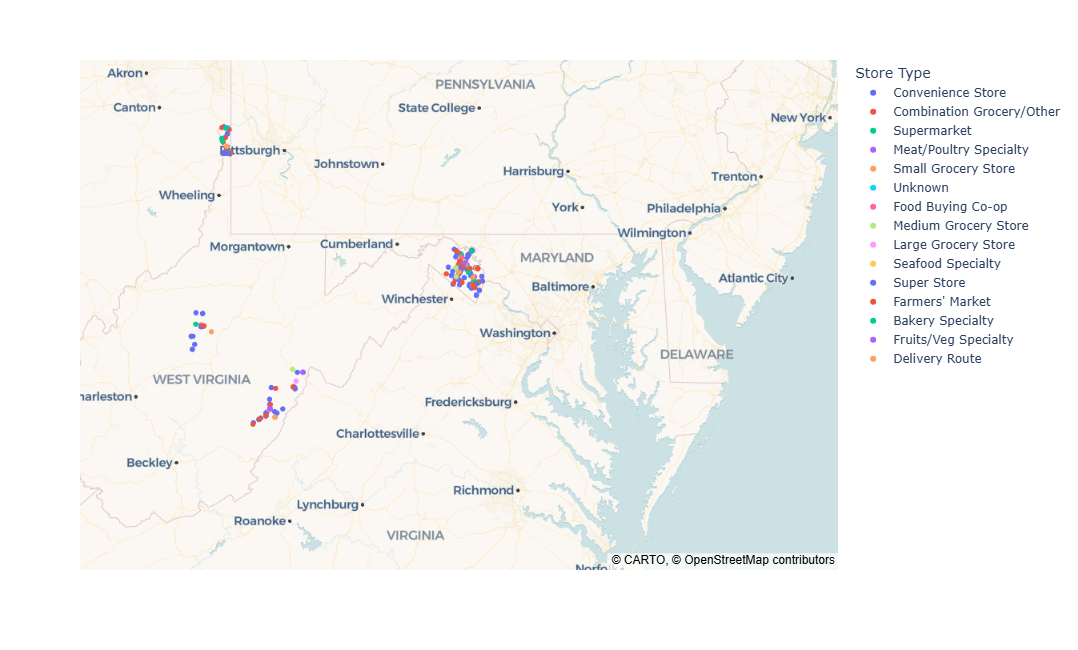

In [167]:
import plotly.express as px

fig = px.scatter_map(
    wv_snap_top5,
    lat="Latitude",
    lon="Longitude",
    color="Store Type",
    hover_name="Store Name",
    hover_data=["City", "County"],
    zoom=6,
    height=650
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [168]:
wv_centroids = wv_snap_top5.groupby("County", as_index=False).agg({
    "Latitude": "mean",
    "Longitude": "mean"
})

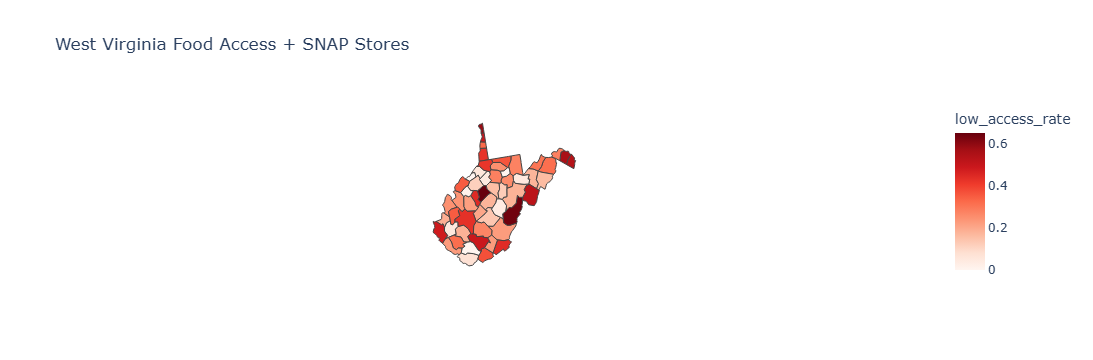

In [169]:
import plotly.express as px

wv_county["fips"] = wv_county["fips"].astype(str).str.zfill(5)

fig = px.choropleth(
    wv_county,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="low_access_rate",
    scope="usa",   # <-- THIS is what prevents world view
    color_continuous_scale="Reds",
    hover_name="County",
    hover_data={
        "low_access_rate": ":.2%",
        "store_count": True
    },
    title="West Virginia Food Access + SNAP Stores"
)

# 🔥 FORCE ZOOM TO WV REGION
fig.update_geos(
    visible=False,
    scope="usa",
    fitbounds="locations"
)

fig.show()

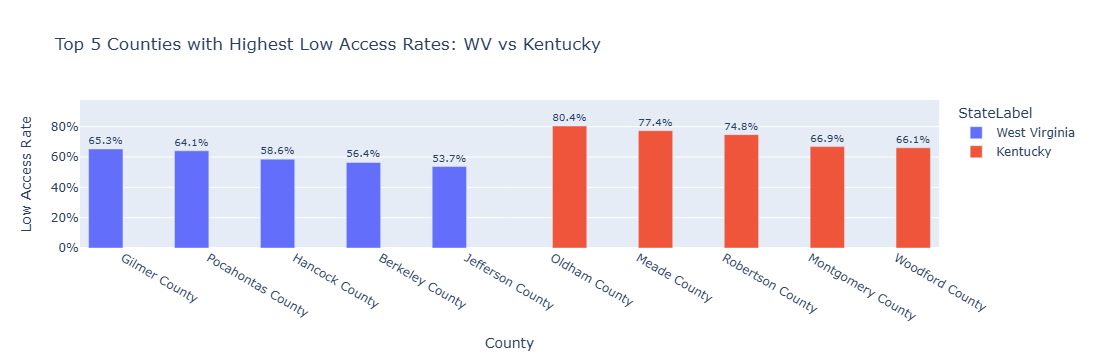

In [170]:
import pandas as pd
import plotly.express as px

# Create county-level averages first
county_rates = df.groupby(
    ["State", "County"],
    as_index=False
)["low_access_rate"].mean()

# Split states
wv_county = county_rates[
    county_rates["State"] == "West Virginia"
]

ky_county = county_rates[
    county_rates["State"] == "Kentucky"
]

# Top 5 for each
wv_top5 = wv_county.sort_values(
    "low_access_rate",
    ascending=False
).head(5)

ky_top5 = ky_county.sort_values(
    "low_access_rate",
    ascending=False
).head(5)

# Add labels
wv_top5["StateLabel"] = "West Virginia"
ky_top5["StateLabel"] = "Kentucky"

# Combine
comparison = pd.concat([wv_top5, ky_top5])

# Plot
fig = px.bar(
    comparison,
    x="County",
    y="low_access_rate",
    color="StateLabel",
    barmode="group",
    text="low_access_rate",
    title="Top 5 Counties with Highest Low Access Rates: WV vs Kentucky"
)

fig.update_traces(
    texttemplate='%{text:.1%}',
    textposition='outside'
)

fig.update_layout(
    yaxis_tickformat=".0%",
    yaxis_title="Low Access Rate",
    xaxis_title="County"
)

fig.show()

In [171]:
stores_gdf.head()
stores_gdf.geometry.type.value_counts()

Polygon    42
Point      23
Name: count, dtype: int64

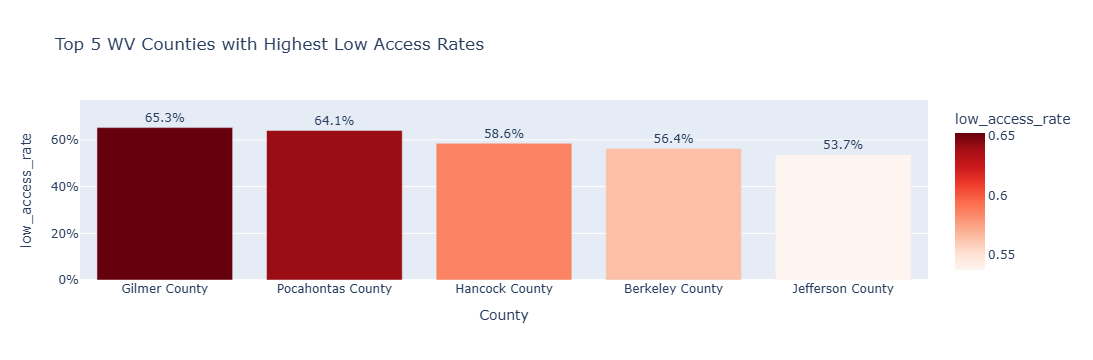

In [172]:
import plotly.express as px

# Top 5 worst counties
top5 = wv_county.sort_values("low_access_rate", ascending=False).head(5)

fig = px.bar(
    top5,
    x="County",
    y="low_access_rate",
    text="low_access_rate",
    color="low_access_rate",
    color_continuous_scale="Reds",
    title="Top 5 WV Counties with Highest Low Access Rates"
)

fig.update_traces(texttemplate='%{text:.1%}', textposition='outside')
fig.update_layout(yaxis_tickformat=".0%")

fig.show()

In [173]:
top5 = wv_county.sort_values("low_access_rate", ascending=False).head(5)

store_cols = [
    "Farmers Market",
    "Full Grocery Access",
    "Limited Access",
    "Other"
]

fig = px.bar(
    top5,
    x="County",
    y=store_cols,
    title="Store Types in Top 5 Worst Access Counties",
    labels={"value": "Store Count", "variable": "Store Type"}
)

fig.show()

ValueError: All arguments should have the same length. The length of argument `y` is 4, whereas the length of previously-processed arguments ['County'] is 5

In [174]:
county = top5.iloc[0]  # pick worst county

pie_data = county[store_cols]

fig = px.pie(
    values=pie_data.values,
    names=pie_data.index,
    title=f"Store Mix in {county['County']}"
)

fig.show()

KeyError: "None of [Index(['Farmers Market', 'Full Grocery Access', 'Limited Access', 'Other'], dtype='object')] are in the [index]"

In [ ]:
wv.shape
wv_county.shape

In [ ]:
wv.columns
wv_county.columns

In [ ]:
"store_count" in app_df.columns

In [ ]:
app_df.columns

In [ ]:
app_county = app_df.groupby("County").agg({
    "PovertyRate": "mean",
    "low_access_rate": "mean",
    "TractSNAP": "sum",
    "TractHUNV": "sum"
}).reset_index()

In [ ]:
app_county = app_df.groupby("County").agg({
    "PovertyRate": "mean",
    "low_access_rate": "mean",
    "TractSNAP": "sum",
    "TractHUNV": "sum"
}).reset_index()

In [ ]:
app_county = app_county.merge(
    wv_county[["County", "store_count"]],
    on="County",
    how="left"
)

In [ ]:
sns.barplot(
    data=wv_county.sort_values("store_count", ascending=False),
    x="store_count",
    y="County"
)
plt.title("WV Counties: Store Counts")
plt.show()

In [175]:
fig = px.bar(
    top5,
    x="County",
    y=store_cols,
    title="Store Types in Top 5 Worst Grocery Access Counties",
    labels={"value": "Store Count", "variable": "Store Type"}
)

fig.show()

ValueError: All arguments should have the same length. The length of argument `y` is 4, whereas the length of previously-processed arguments ['County'] is 5